In [49]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from scipy.stats import entropy
import matplotlib.pyplot as plt
from collections import deque
import gc

# Styling for elegant plots
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Toy Environment Ready. Using device: {device} ---")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

class GridWorldMDP:
    """A 4x4 Gridworld. Start at 0 (top-left), Goal at 15 (bottom-right)."""
    def __init__(self, size=4):
        self.size = size
        self.n = size * size
        self.state = 0
        self.action_space = [0, 1, 2, 3] # 0:Up, 1:Right, 2:Down, 3:Left

    def reset(self):
        self.state = 0
        return self._one_hot(self.state)

    def step(self, action):
        row = self.state // self.size
        col = self.state % self.size

        if action == 0 and row > 0: row -= 1       # Up
        elif action == 1 and col < self.size - 1: col += 1 # Right
        elif action == 2 and row < self.size - 1: row += 1 # Down
        elif action == 3 and col > 0: col -= 1     # Left
        
        self.state = row * self.size + col
        
        reward = 1.0 if self.state == self.n - 1 else 0.0
        done = self.state == self.n - 1
        return self._one_hot(self.state), reward, done

    def _one_hot(self, s):
        v = np.zeros(self.n, dtype=np.float32)
        v[s] = 1.0
        return v

# --- IMPORTANT ORCHESTRATOR UPDATE ---
# When you instantiate the models in your orchestrator, make sure they match the new sizes:
# state_dim = 16 (for a 4x4 grid)
# action_dim = 4 (Up, Right, Down, Left)
# e.g., agent = TinyDQN(state_dim=16, action_dim=4).to(device)
# e.g., gen_model = ToyGenerativeModel(state_dim=16, action_dim=4).to(device)

--- Toy Environment Ready. Using device: cuda ---


True Q* Calculated and Loaded to Device.
--- Training DQN on 4x4 Gridworld (Sparse Reward) ---


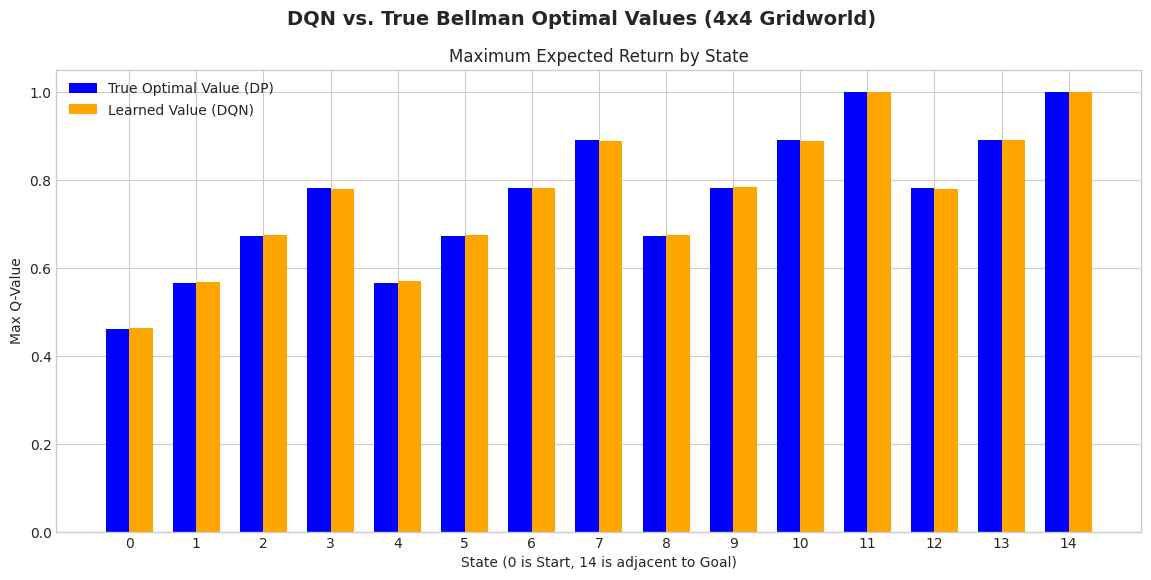

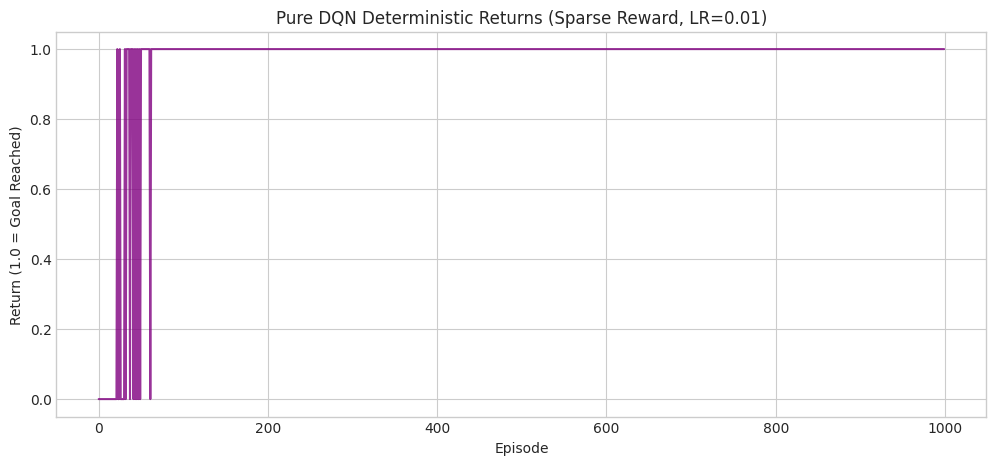

In [50]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

# --- 1. TRUE DYNAMIC PROGRAMMING (16-State Gridworld) ---
n_states = 16
n_actions = 4 # 0:Up, 1:Right, 2:Down, 3:Left
size = 4
gamma = 0.99
Q_star = np.zeros((n_states, n_actions))
V_star = np.zeros(n_states)

def get_next_state(s, a):
    row, col = s // size, s % size
    if a == 0 and row > 0: row -= 1
    elif a == 1 and col < size - 1: col += 1
    elif a == 2 and row < size - 1: row += 1
    elif a == 3 and col > 0: col -= 1
    return row * size + col

for _ in range(1000):
    for s in range(n_states - 1): # State 15 is terminal
        for a in range(n_actions):
            ns = get_next_state(s, a)
            r = 1.0 if ns == 15 else -0.1
            if ns == 15: Q_star[s, a] = r
            else: Q_star[s, a] = r + gamma * V_star[ns]
        V_star[s] = np.max(Q_star[s])

Q_star_tensor = torch.FloatTensor(Q_star).to(device)
print("True Q* Calculated and Loaded to Device.")

# --- 2. THE DQN AGENT ---
class TinyDQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, 4))
    def forward(self, x): return self.net(x)

def one_hot(s):
    v = np.zeros(16, dtype=np.float32)
    v[s] = 1.0
    return v

env = GridWorldMDP()
agent = TinyDQN()
target_agent = TinyDQN()
target_agent.load_state_dict(agent.state_dict())
optimizer = optim.Adam(agent.parameters(), lr=0.01)
buffer = []

epsilon = 1.0
epsilon_decay = 0.99
batch_size = 64
gamma = 0.99
eval_returns = []

print("--- Training DQN on 4x4 Gridworld (Sparse Reward) ---")
for ep in range(1000): # Given 1000 episodes to try and learn
    s = 0
    # Increased to 50 steps so it has time to wander to the goal
    for step in range(50): 
        if random.random() < epsilon: a = random.randint(0, 3)
        else: a = agent(torch.FloatTensor(one_hot(s))).argmax().item()
        
        ns = get_next_state(s, a)
        r = 1.0 if ns == 15 else -0.1
        done = (ns == 15)
        
        buffer.append((one_hot(s), a, r, one_hot(ns), done))
        if len(buffer) > 5000: buffer.pop(0)
        s = ns
        
        if len(buffer) >= batch_size:
            batch = random.sample(buffer, batch_size)
            states = torch.FloatTensor(np.array([x[0] for x in batch]))
            actions = torch.tensor([x[1] for x in batch]).long().unsqueeze(1)
            rewards = torch.FloatTensor([x[2] for x in batch])
            next_states = torch.FloatTensor(np.array([x[3] for x in batch]))
            dones = torch.FloatTensor([x[4] for x in batch])
            
            q_vals = agent(states).gather(1, actions).squeeze(1)
            next_q_vals = target_agent(next_states).max(1)[0]
            expected_q = rewards + gamma * next_q_vals * (1 - dones)
            
            loss = F.mse_loss(q_vals, expected_q.detach())
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        if done: break
    epsilon = max(0.01, epsilon * epsilon_decay)
    if ep % 10 == 0: target_agent.load_state_dict(agent.state_dict())

    test_s = env.reset()
    test_ret = 0
    for _ in range(50):
        with torch.no_grad():
            test_a = agent(torch.FloatTensor(test_s)).argmax().item()
        test_ns, test_r, test_done = env.step(test_a)
        test_ret += test_r
        test_s = test_ns
        if test_done: break
    eval_returns.append(test_ret)

# Extract Learned Q-Values
Q_dqn = np.zeros((n_states, n_actions))
with torch.no_grad():
    for s in range(n_states - 1): Q_dqn[s] = agent(torch.FloatTensor(one_hot(s))).numpy()

# --- 3. PLOTTING THE COMPARISON ---
states_x = np.arange(15) 
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("DQN vs. True Bellman Optimal Values (4x4 Gridworld)", fontsize=14, fontweight='bold')

# Plot Max Q-value for each state (V(s))
V_dqn = np.max(Q_dqn, axis=1)[:15]


ax.bar(states_x - width/2, V_star[:15], width, label='True Optimal Value (DP)', color='blue')
ax.bar(states_x + width/2, V_dqn, width, label='Learned Value (DQN)', color='orange')
ax.set_title("Maximum Expected Return by State")
ax.set_xlabel("State (0 is Start, 14 is adjacent to Goal)"); ax.set_ylabel("Max Q-Value")
ax.set_xticks(states_x)
ax.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(eval_returns, color='purple', alpha=0.8, linewidth=1.5)
plt.title("Pure DQN Deterministic Returns (Sparse Reward, LR=0.01)")
plt.xlabel("Episode")
plt.ylabel("Return (1.0 = Goal Reached)")
plt.grid(True)
plt.show()

In [51]:
class ToyGenerativeModel(nn.Module):
    def __init__(self, state_dim=5, action_dim=2):
        super().__init__()
        # Input: state + action (one-hot) -> Output: Next state logits
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 32), nn.ReLU(),
            nn.Linear(32, state_dim)
        )

    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=-1))

    def sample(self, s, a):
        """Generates synthetic next states instantaneously."""
        self.eval()
        with torch.no_grad():
            logits = self.forward(s, a)
            probs = F.softmax(logits, dim=-1)
            next_s_idx = torch.multinomial(probs, 1)
            next_s = torch.zeros_like(logits).scatter_(1, next_s_idx, 1.0)
        self.train()
        return next_s.cpu().numpy()

class RecursiveDataManager:
    def __init__(self, capacity=10000): # Increased capacity
        self.real_buffer = deque(maxlen=capacity)  
        self.mu_n_minus_1 = []                     
        self.current_mu_n = []                     
        
    def push_real(self, transition):
        self.real_buffer.append(transition)
        
    def form_empirical_batch(self, gen_model, N, a, b, c):
        n_a, n_b = int(N * a), int(N * b)
        n_c = N - n_a - n_b
        new_batch = [] 
        
        # FIX: Sample WITHOUT replacement for clean gradients
        if n_a > 0 and len(self.real_buffer) > 0:
            if len(self.real_buffer) >= n_a:
                new_batch.extend(random.sample(self.real_buffer, n_a))
            else:
                new_batch.extend(random.choices(self.real_buffer, k=n_a))
        
        if n_b > 0 and len(self.real_buffer) > 0:
            # Seed the generator with unique real states
            sample_size = min(n_b, len(self.real_buffer))
            seeds = random.sample(self.real_buffer, sample_size)
            # If we need more synthetic data than we have real seeds, duplicate seeds safely
            while len(seeds) < n_b: seeds.append(random.choice(self.real_buffer))
            
            s_t = torch.FloatTensor(np.array([x[0] for x in seeds])).to(device)
            a_t = F.one_hot(torch.tensor([x[1] for x in seeds]), num_classes=4).float().to(device)
            ns_syn = gen_model.sample(s_t, a_t)
            for i in range(n_b):
                new_batch.append((seeds[i][0], seeds[i][1], seeds[i][2], ns_syn[i], seeds[i][4]))
                
        if n_c > 0 and len(self.mu_n_minus_1) > 0: 
            if len(self.mu_n_minus_1) >= n_c:
                new_batch.extend(random.sample(self.mu_n_minus_1, n_c))
            else:
                new_batch.extend(random.choices(self.mu_n_minus_1, k=n_c))
            
        while len(new_batch) < N: 
            new_batch.extend(random.choices(self.real_buffer, k=1))
            
        self.mu_n_minus_1 = self.current_mu_n.copy() if isinstance(self.current_mu_n, list) else list(self.current_mu_n)
        self.current_mu_n = new_batch 
        return self.current_mu_n

    def sample_policy_mixture(self, batch_size, a_p, b_p, c_p, gen_model):
        n_a, n_b = int(batch_size * a_p), int(batch_size * b_p)
        n_c = batch_size - n_a - n_b
        batch = []
        
        # FIX: Sample WITHOUT replacement
        if n_a > 0 and len(self.real_buffer) > 0: 
            if len(self.real_buffer) >= n_a:
                batch.extend(random.sample(self.real_buffer, n_a))
            else:
                batch.extend(random.choices(self.real_buffer, k=n_a))
                
        if n_b > 0 and len(self.real_buffer) > 0:
            sample_size = min(n_b, len(self.real_buffer))
            seeds = random.sample(self.real_buffer, sample_size)
            while len(seeds) < n_b: seeds.append(random.choice(self.real_buffer))
                
            s_t = torch.FloatTensor(np.array([x[0] for x in seeds])).to(device)
            a_t = F.one_hot(torch.tensor([x[1] for x in seeds]), num_classes=4).float().to(device)
            ns_syn = gen_model.sample(s_t, a_t)
            for i in range(n_b): batch.append((seeds[i][0], seeds[i][1], seeds[i][2], ns_syn[i], seeds[i][4]))
                
        if n_c > 0 and len(self.current_mu_n) > 0:
            if len(self.current_mu_n) >= n_c:
                batch.extend(random.sample(self.current_mu_n, n_c))
            else:
                batch.extend(random.choices(self.current_mu_n, k=n_c))
                
        while len(batch) < batch_size: batch.extend(random.choices(self.real_buffer, k=1))
        return batch

In [52]:
class TinyDQN(nn.Module):
    def __init__(self, state_dim=16, action_dim=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim, 32), nn.ReLU(), nn.Linear(32, action_dim))
    def forward(self, x): return self.net(x)

def train_generative_model(model, optimizer, batch):
    if not batch: return
    s = torch.FloatTensor(np.array([x[0] for x in batch])).to(device)
    # UPDATED: num_classes=4 for the 4 Gridworld actions
    a = F.one_hot(torch.tensor([x[1] for x in batch]), num_classes=4).float().to(device)
    ns_target = torch.tensor([np.argmax(x[3]) for x in batch]).to(device) 
    
    logits = model(s, a)
    loss = F.cross_entropy(logits, ns_target)
    optimizer.zero_grad(); loss.backward(); optimizer.step()

def train_policy_step(agent, target_agent, optimizer, batch, gamma=0.99):
    if not batch: return
    states = torch.FloatTensor(np.array([x[0] for x in batch])).to(device)
    actions = torch.tensor([x[1] for x in batch]).long().to(device).unsqueeze(1)
    rewards = torch.FloatTensor([x[2] for x in batch]).to(device)
    next_states = torch.FloatTensor(np.array([x[3] for x in batch])).to(device)
    dones = torch.FloatTensor([x[4] for x in batch]).to(device)

    q_values = agent(states).gather(1, actions).squeeze(1)
    best_next_actions = agent(next_states).argmax(dim=1, keepdim=True)
    next_q_values = target_agent(next_states).gather(1, best_next_actions).squeeze(1)
    expected_q_values = rewards + gamma * next_q_values * (1 - dones)

    loss = F.mse_loss(q_values, expected_q_values.detach())
    optimizer.zero_grad(); loss.backward(); optimizer.step()

In [53]:
def run_toy_experiment(label, episodes=1000, a=1.0, b=0.0, c=0.0, a_p=1.0, b_p=0.0, c_p=0.0, utd_ratio=5):
    print(f"--- Starting: {label} ---")
    env = GridWorldMDP()
    data_manager = RecursiveDataManager(capacity=10000) 
    
    agent = TinyDQN(state_dim=16, action_dim=4).to(device)
    target_agent = TinyDQN(state_dim=16, action_dim=4).to(device)
    target_agent.load_state_dict(agent.state_dict())
    optimizer = optim.Adam(agent.parameters(), lr=0.001) # Stable LR
    
    gen_model = ToyGenerativeModel(state_dim=16, action_dim=4).to(device)
    gen_optimizer = optim.Adam(gen_model.parameters(), lr=0.01)
    
    metrics = {
        'returns': [], 'gen_entropy': [], 'gen_tvd': [], 
        'ctrl_q_variance': [], 'ctrl_action_entropy': [],
        'mse_q': [], 'buffer_coverage': [] # NEW METRICS
    }
    
    holdout_states = torch.eye(16).float().to(device) 
    epsilon = 1.0
    epsilon_decay = 0.99 
    
    for ep in range(episodes):
        state = env.reset()
        
        # 1. TRAINING PHASE
        for step in range(50): 
            if random.random() < epsilon: action = random.choice(env.action_space)
            else:
                with torch.no_grad(): action = agent(torch.FloatTensor(state).to(device)).argmax().item()
                    
            next_state, reward, done = env.step(action)
            data_manager.push_real((state, action, reward, next_state, done))
            state = next_state
            
            if len(data_manager.real_buffer) > 64 and step % 5 == 0:
                mu_n_batch = data_manager.form_empirical_batch(gen_model, 256, a, b, c)
                train_generative_model(gen_model, gen_optimizer, mu_n_batch)
                
                for _ in range(utd_ratio):
                    policy_batch = data_manager.sample_policy_mixture(64, a_p, b_p, c_p, gen_model)
                    train_policy_step(agent, target_agent, optimizer, policy_batch)
            if done: break
            
        epsilon = max(0.01, epsilon * epsilon_decay)
        if ep % 10 == 0: target_agent.load_state_dict(agent.state_dict())

        # 2. EVALUATION PHASE
        if len(data_manager.real_buffer) > 64:
            # Generative Metrics
            seeds = random.choices(data_manager.real_buffer, k=256)
            s_t = torch.FloatTensor(np.array([x[0] for x in seeds])).to(device)
            a_t = F.one_hot(torch.tensor([x[1] for x in seeds]), num_classes=4).float().to(device)
            syn_ns = gen_model.sample(s_t, a_t)
            
            syn_ns_idx = np.array([np.argmax(x) for x in syn_ns])
            real_ns_idx = np.array([np.argmax(x[3]) for x in data_manager.real_buffer])
            
            counts = np.bincount(syn_ns_idx, minlength=16)
            metrics['gen_entropy'].append(entropy((counts / (counts.sum() + 1e-9)) + 1e-9))
            
            real_probs = np.bincount(real_ns_idx, minlength=16) / (len(real_ns_idx) + 1e-9)
            metrics['gen_tvd'].append(0.5 * np.sum(np.abs((counts / (counts.sum() + 1e-9)) - real_probs)))
            
            # --- NEW METRIC: BUFFER COVERAGE ---
            if hasattr(data_manager, 'current_mu_n') and len(data_manager.current_mu_n) > 0:
                unique_states = len(set([np.argmax(x[0]) for x in data_manager.current_mu_n]))
                metrics['buffer_coverage'].append(unique_states / 16.0)
            else:
                metrics['buffer_coverage'].append(0.0)
        else:
            metrics['gen_entropy'].append(0.0); metrics['gen_tvd'].append(0.0); metrics['buffer_coverage'].append(0.0)

        # Control Metrics & Deterministic Episode
        with torch.no_grad():
            q_vals = agent(holdout_states)
            max_q, best_actions = q_vals.max(dim=1)
            metrics['ctrl_q_variance'].append(torch.var(max_q).item())
            a_counts = torch.bincount(best_actions, minlength=4).float()
            metrics['ctrl_action_entropy'].append(entropy((a_counts / a_counts.sum()).cpu().numpy() + 1e-9))
            
            # --- NEW METRIC: Q-VALUE MSE ---
            # We evaluate MSE only on the first 15 states, as state 15 is terminal and never acted upon
            mse = F.mse_loss(q_vals[:15], Q_star_tensor[:15]).item()
            metrics['mse_q'].append(mse)

        test_state = env.reset()
        test_return = 0
        for _ in range(50):
            with torch.no_grad(): best_action = agent(torch.FloatTensor(test_state).to(device)).argmax().item()
            next_state, reward, done = env.step(best_action)
            test_return += reward
            test_state = next_state
            if done: break
        metrics['returns'].append(test_return)
            
    return metrics

In [54]:
# Run 1000 episodes to ensure it fully converges
m_perfect = run_toy_experiment("1. Baseline (Perfect Learning)", episodes=1000, a=1.0, b=0.0, c=0.0, a_p=1.0, b_p=0.0, c_p=0.0)
m_diffusion_mixed = run_toy_experiment("2. Diffusion Mixed", episodes=1000, a=0.5, b=0.25, c=0.25, a_p=1.0, b_p=0.0, c_p=0.0)
m_perfect_model_mixed_policy = run_toy_experiment("3. Baseline (Stable Learning)", episodes=1000, a=1.0, b=0.0, c=0.0, a_p=0.5, b_p=0.5, c_p=0.0)
m_model_collapse_mixed_policy = run_toy_experiment("4. Generative Model Collapse mixed policy", episodes=1000, a=0.0, b=1.0, c=0.0, a_p=0.5, b_p=0.5, c_p=0.0)
m_model_collapse_synthetic_policy = run_toy_experiment("5.Model collapse and Only Synthetic Data for Policy", episodes=1000, a=0.0, b=0.5, c=0.5, a_p=0.0, b_p=1.0, c_p=0.0)
m_control_collapse_two = run_toy_experiment("6. Control Collapse two", episodes=1000, a=0.0, b=0.0, c=1.0, a_p=0.0, b_p=0.0, c_p=1.0)
m_synthetic_synthetic = run_toy_experiment("7. Only Synthetic Data for Both", episodes=1000, a=0.0, b=1.0, c=0.0, a_p=0.0, b_p=1.0, c_p=0.0)





--- Starting: 1. Baseline (Perfect Learning) ---
--- Starting: 2. Diffusion Mixed ---
--- Starting: 3. Baseline (Stable Learning) ---
--- Starting: 4. Generative Model Collapse mixed policy ---
--- Starting: 5.Model collapse and Only Synthetic Data for Policy ---
--- Starting: 6. Control Collapse two ---
--- Starting: 7. Only Synthetic Data for Both ---


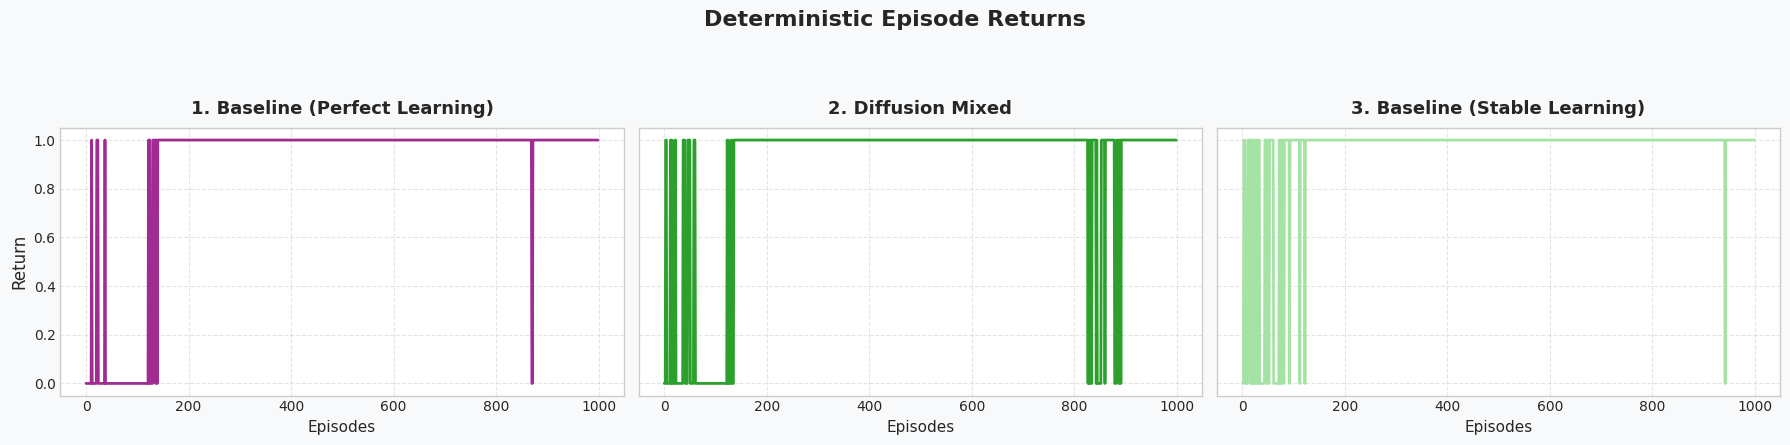

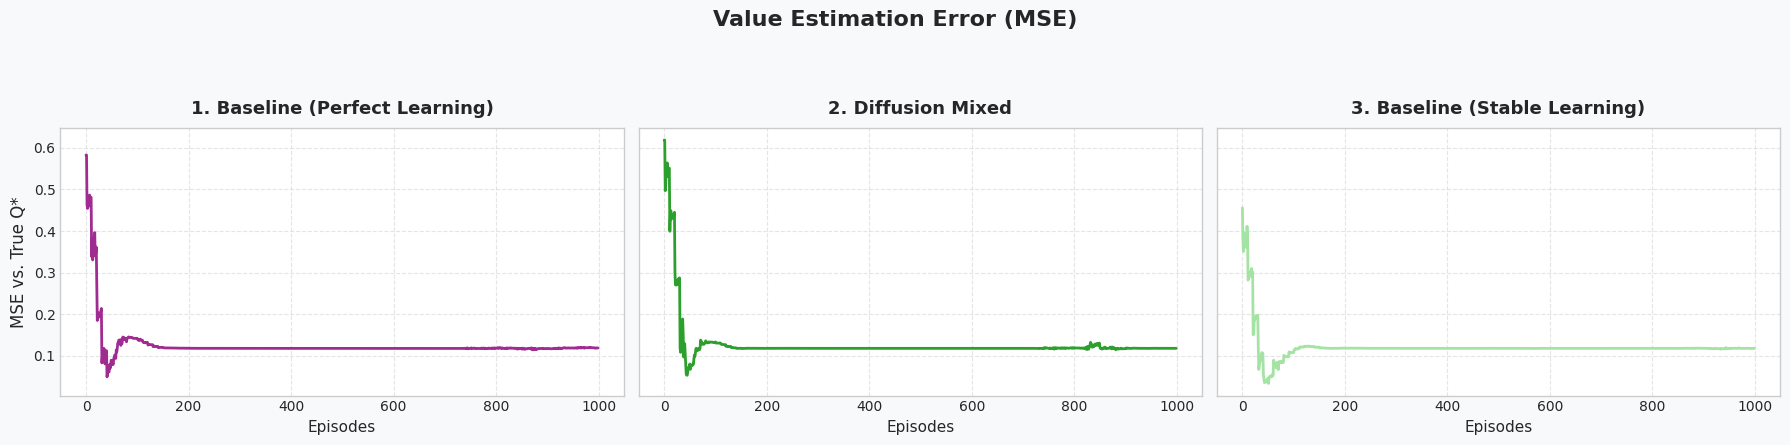

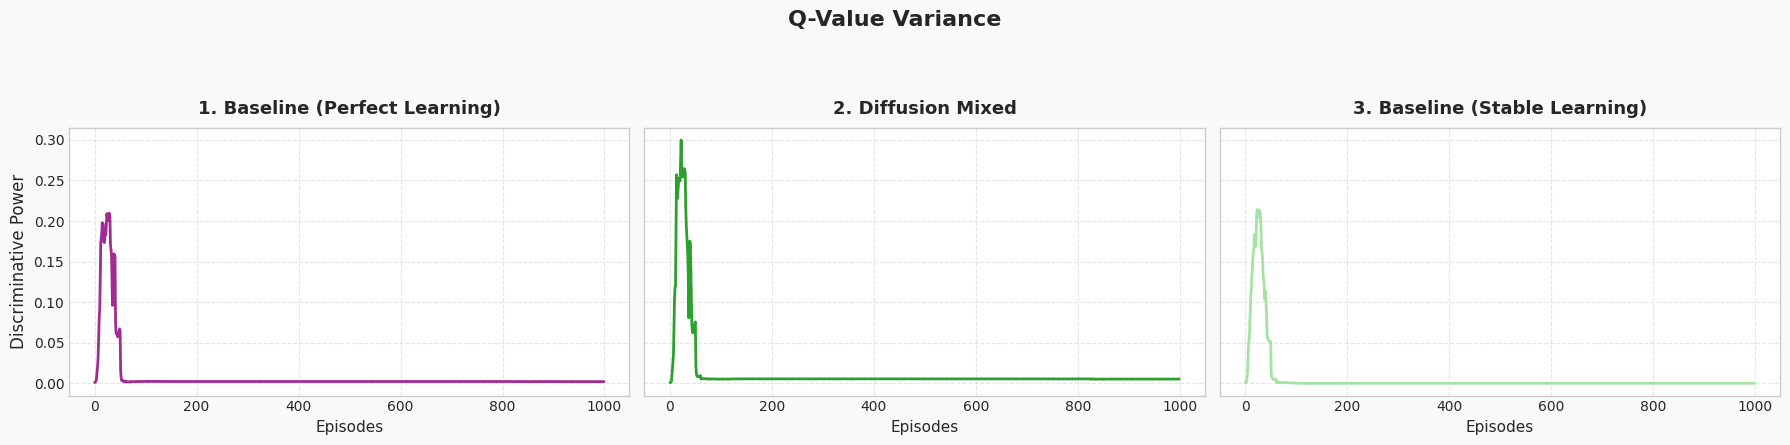

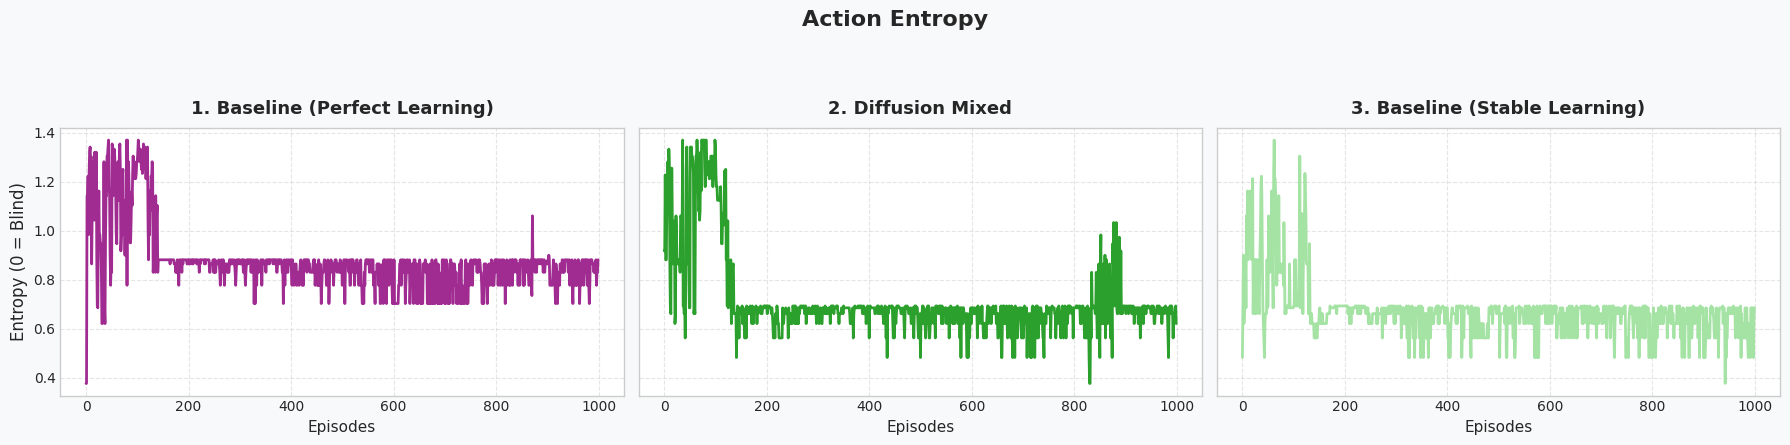

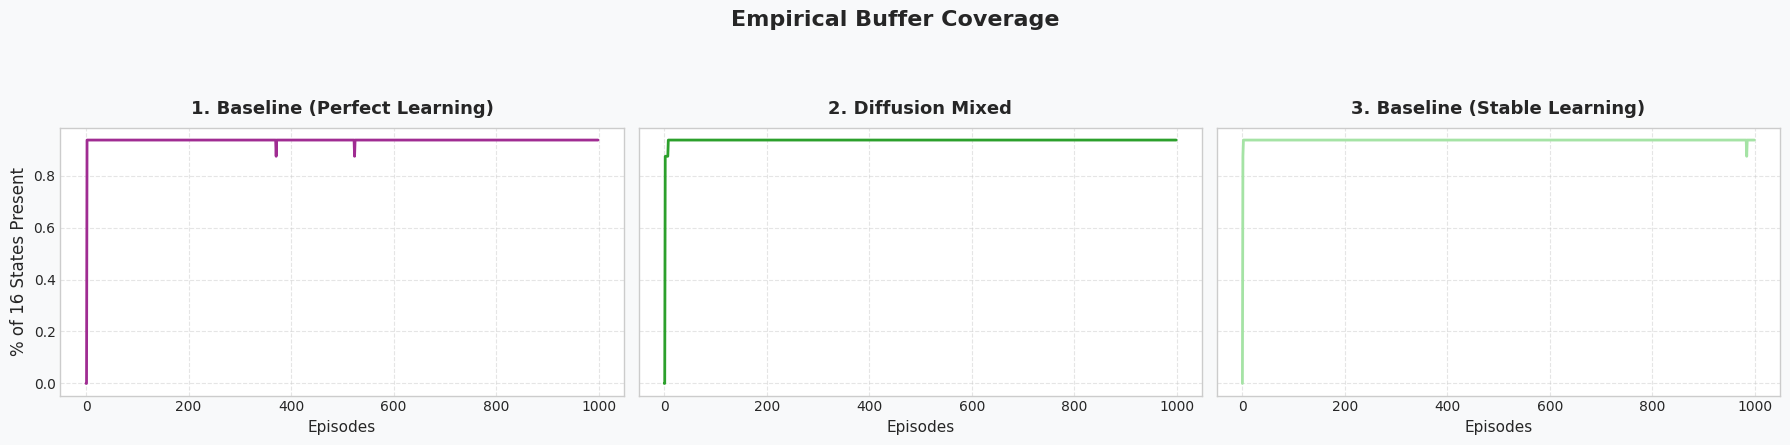

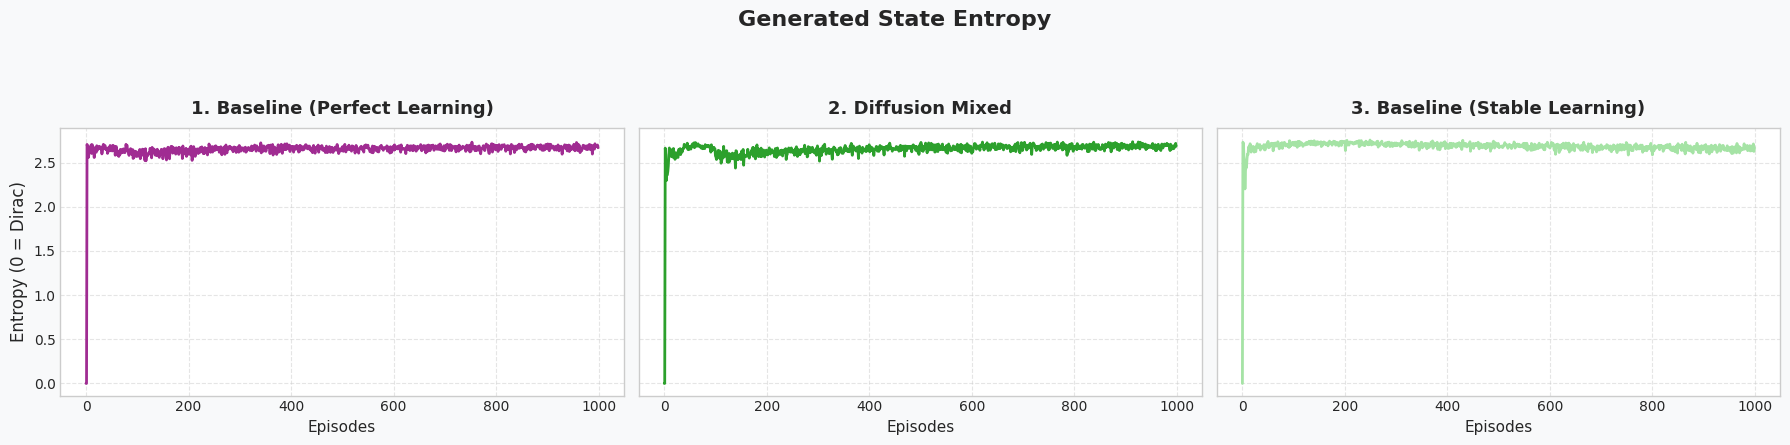

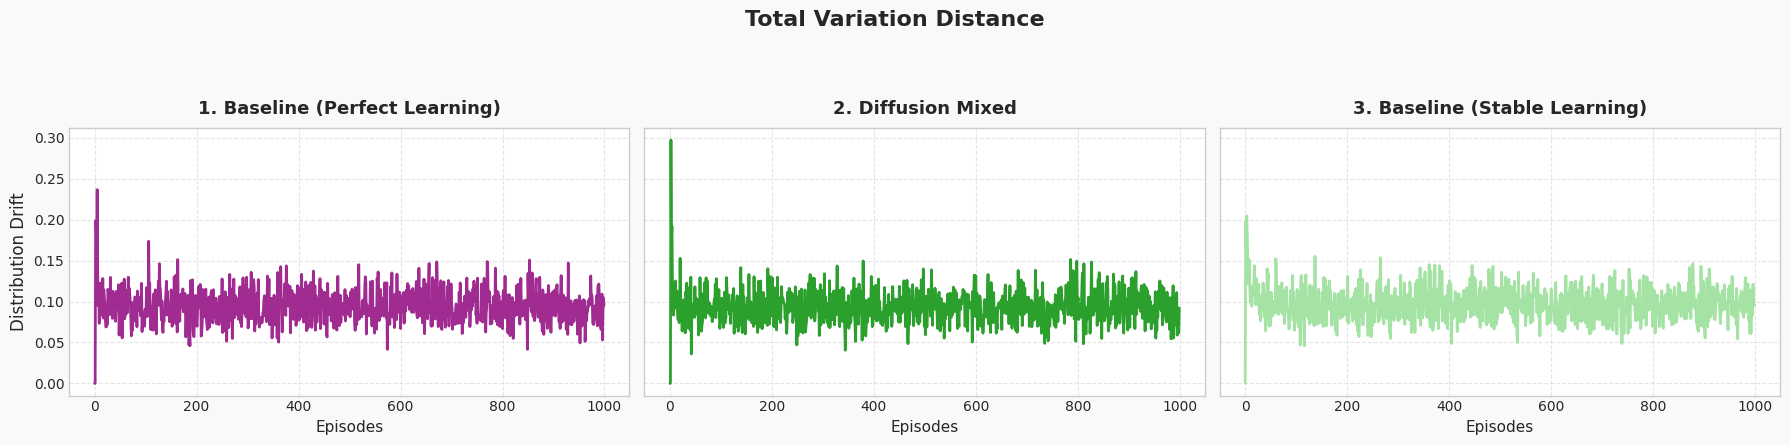

In [57]:
# --- ELEGANT SEPARATED PLOTTING ---
import matplotlib.pyplot as plt

metrics_to_plot = [
    ('returns', "Deterministic Episode Returns", "Return"),
    ('mse_q', "Value Estimation Error (MSE)", "MSE vs. True Q*"),
    ('ctrl_q_variance', "Q-Value Variance", "Discriminative Power"),
    ('ctrl_action_entropy', "Action Entropy", "Entropy (0 = Blind)"),
    ('buffer_coverage', "Empirical Buffer Coverage", "% of 16 States Present"),
    ('gen_entropy', "Generated State Entropy", "Entropy (0 = Dirac)"),
    ('gen_tvd', "Total Variation Distance", "Distribution Drift")
]

colors = {'Baseline (Perfect Learning)': "#a02c92", 'Diffusion Mixed': '#2ca02c', 'Baseline (Stable Learning)': "#a5e3a5", 'Generative Model Collapse mixed policy': '#ff7f0e', 'Model collapse and Only Synthetic Data for Policy': '#d62728',
          'Control Collapse two' : "#dde26f", 'Only Synthetic Data for Both' : "#be6b96" }
data_dicts = [
    ('1. Baseline (Perfect Learning)', m_perfect, colors['Baseline (Perfect Learning)']), 
    ('2. Diffusion Mixed', m_diffusion_mixed, colors['Diffusion Mixed']), 
    ('3. Baseline (Stable Learning)', m_perfect_model_mixed_policy, colors['Baseline (Stable Learning)'])
]

# Create a separate figure for each metric to keep them large and legible
for metric_key, title, ylabel in metrics_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor='#f8f9fa', sharey=True)
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.1)
    
    for i, (name, data, color) in enumerate(data_dicts):
        ax = axes[i]
        
        # Plot the data if it exists
        if metric_key in data and len(data[metric_key]) > 0:
            ax.plot(data[metric_key], color=color, linewidth=2.0)
            
        ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel("Episodes", fontsize=11)
        
        # Only put the Y-label on the far-left graph since they share the Y-axis
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=12)
            
        ax.grid(True, alpha=0.5, linestyle='--')
        
    plt.tight_layout()
    plt.show()

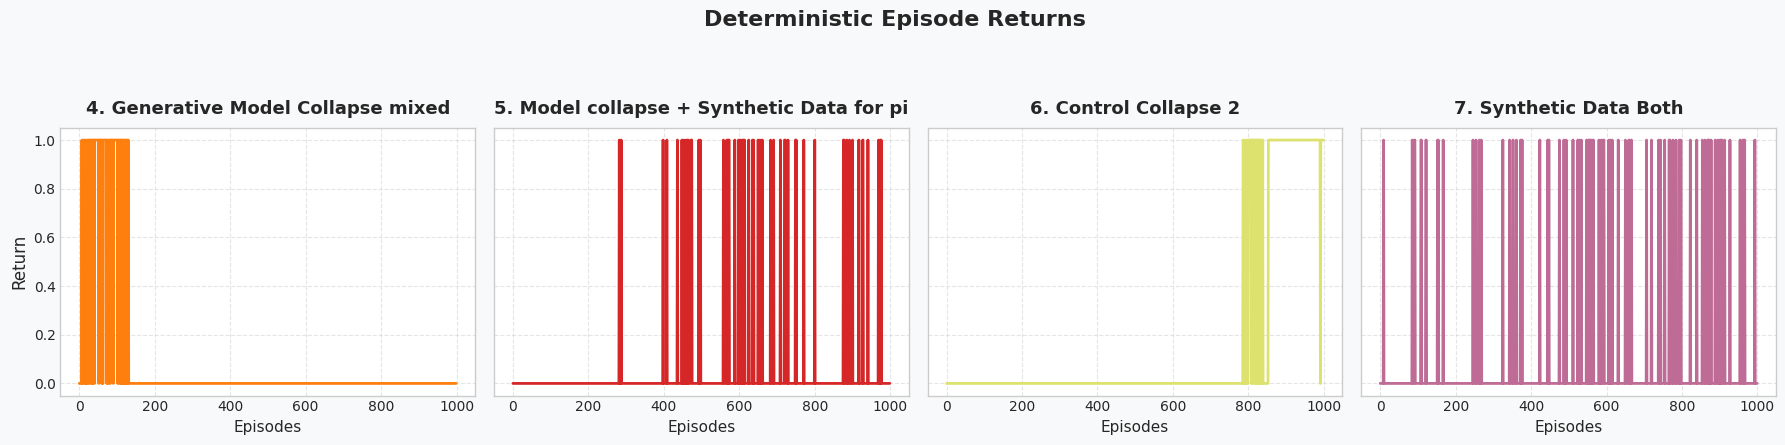

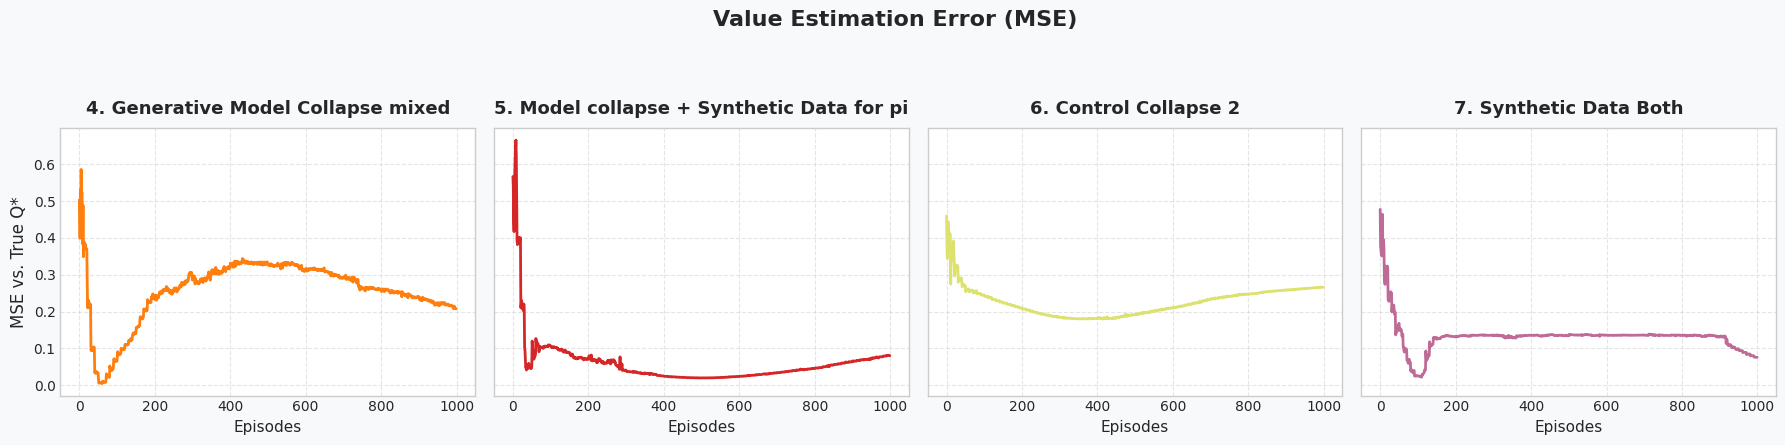

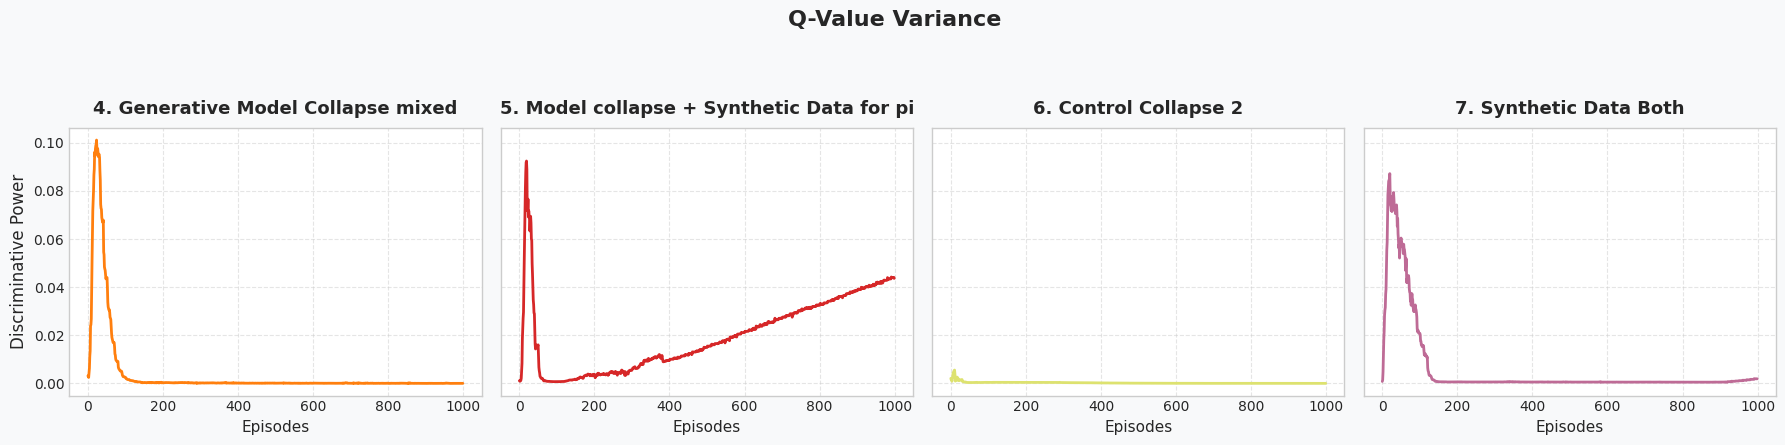

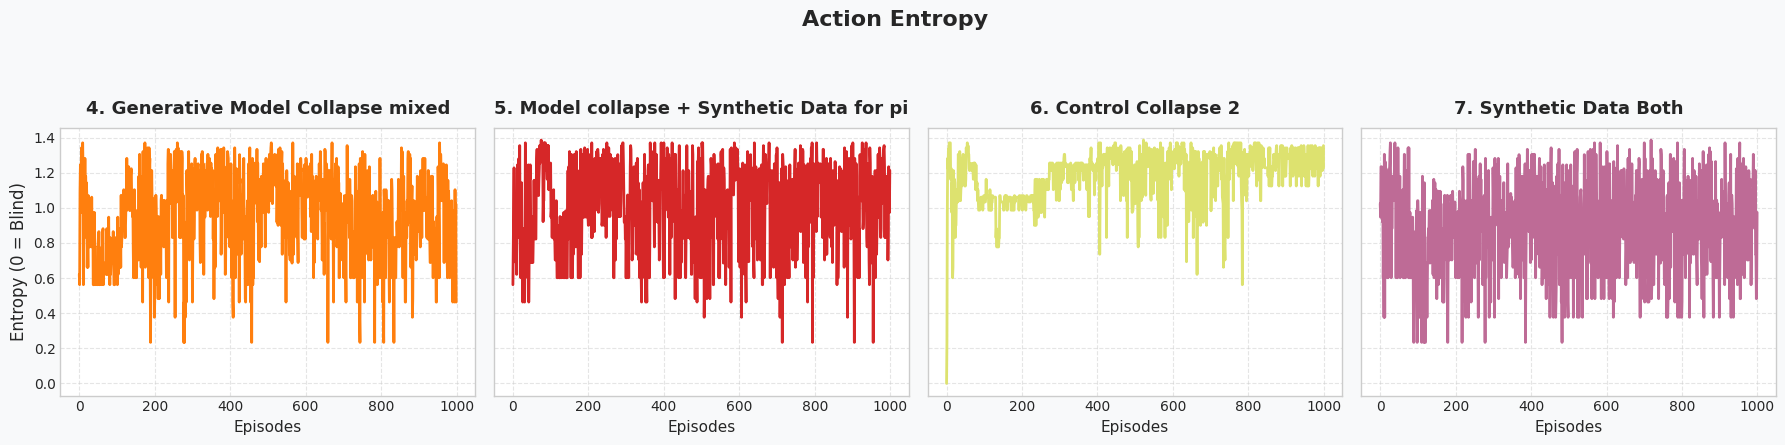

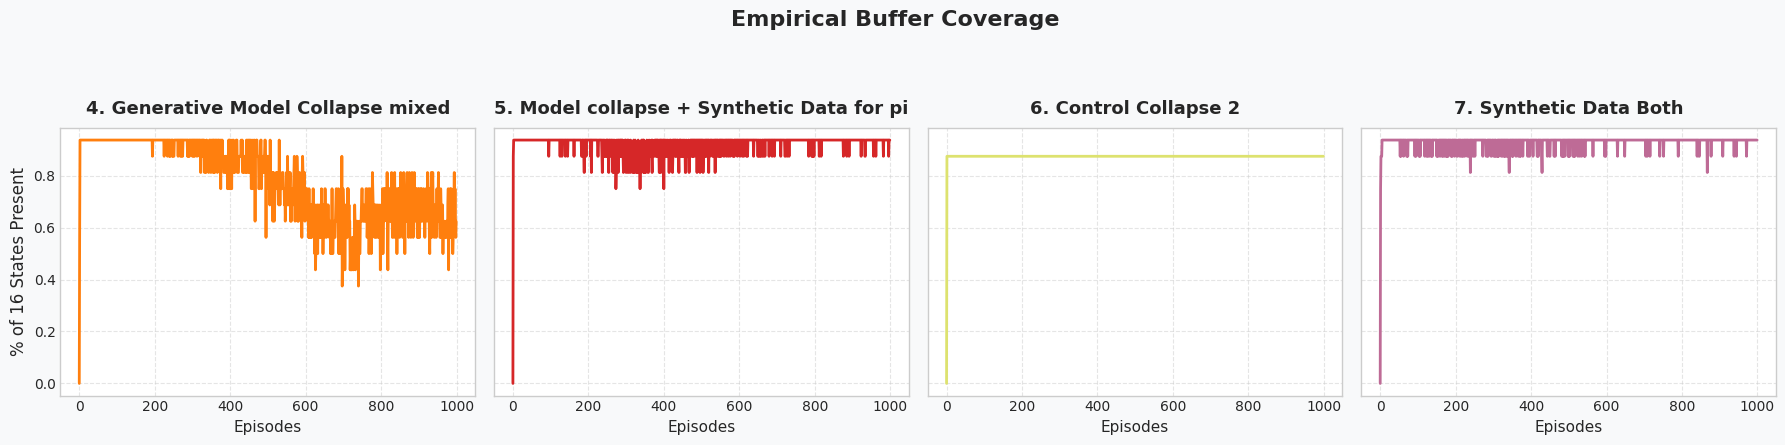

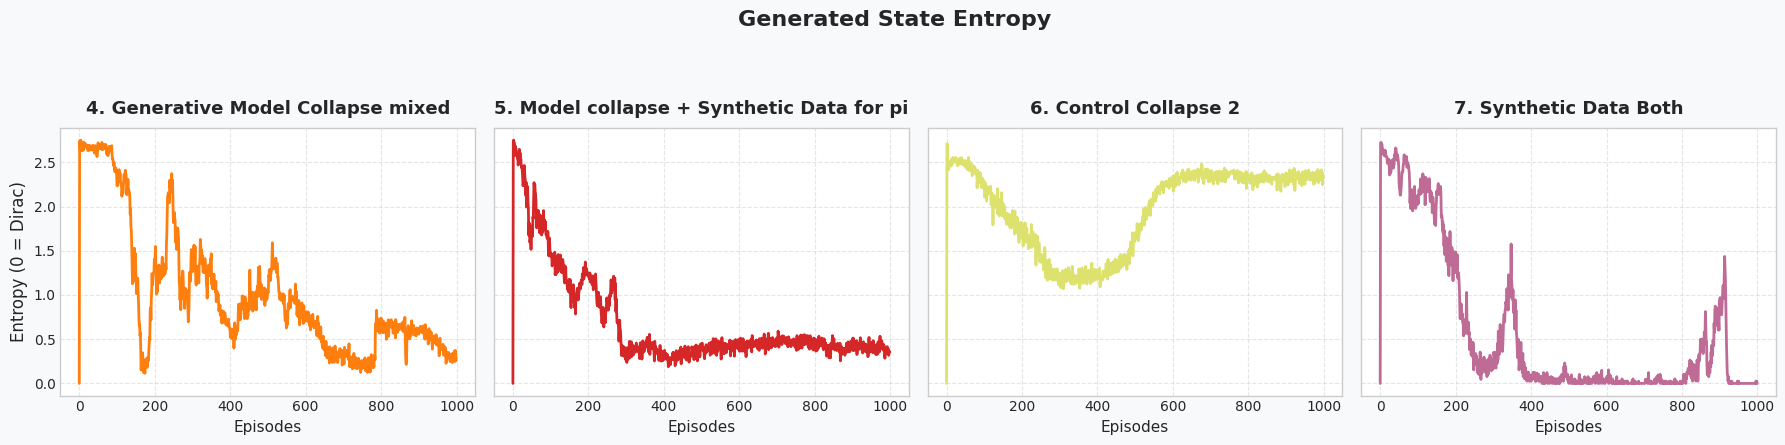

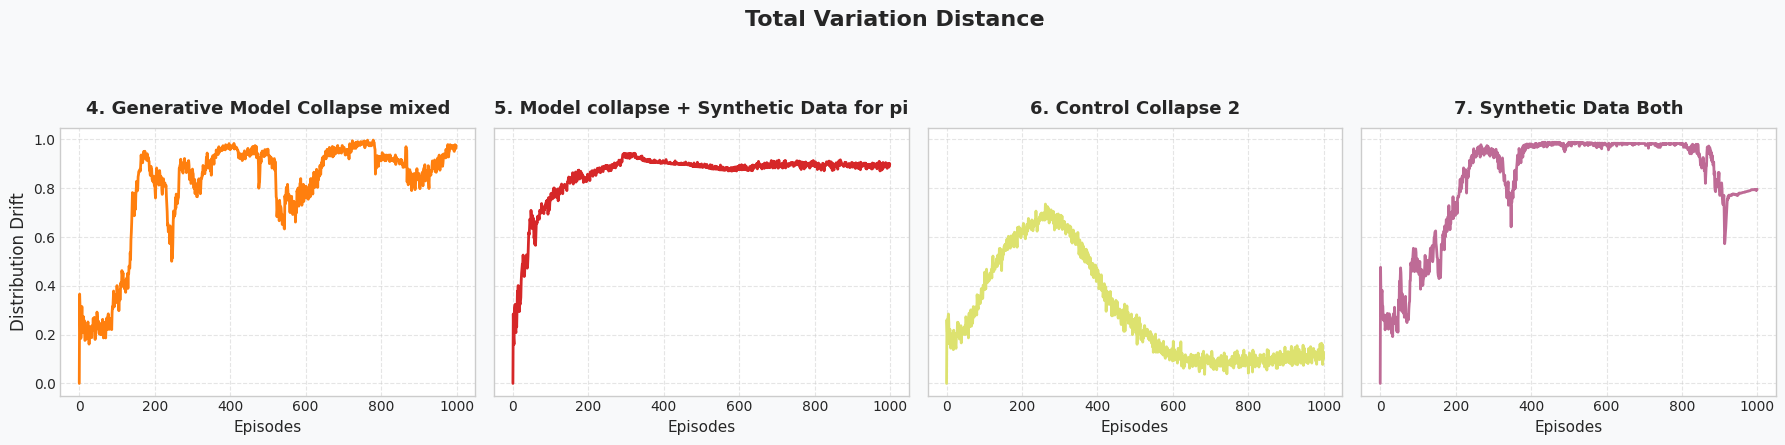

In [59]:
# --- ELEGANT SEPARATED PLOTTING ---
import matplotlib.pyplot as plt

metrics_to_plot = [
    ('returns', "Deterministic Episode Returns", "Return"),
    ('mse_q', "Value Estimation Error (MSE)", "MSE vs. True Q*"),
    ('ctrl_q_variance', "Q-Value Variance", "Discriminative Power"),
    ('ctrl_action_entropy', "Action Entropy", "Entropy (0 = Blind)"),
    ('buffer_coverage', "Empirical Buffer Coverage", "% of 16 States Present"),
    ('gen_entropy', "Generated State Entropy", "Entropy (0 = Dirac)"),
    ('gen_tvd', "Total Variation Distance", "Distribution Drift")
]

colors = {'Baseline (Perfect Learning)': "#a02c92", 'Diffusion Mixed': '#2ca02c', 'Baseline (Stable Learning)': "#a5e3a5", 'Generative Model Collapse mixed policy': '#ff7f0e', 'Model collapse and Only Synthetic Data for Policy': '#d62728',
          'Control Collapse two' : "#dde26f", 'Only Synthetic Data for Both' : "#be6b96" }
data_dicts = [
    ('4. Generative Model Collapse mixed', m_model_collapse_mixed_policy, colors['Generative Model Collapse mixed policy']),
    ('5. Model collapse + Synthetic Data for pi', m_model_collapse_synthetic_policy, colors['Model collapse and Only Synthetic Data for Policy']),
    ('6. Control Collapse 2', m_control_collapse_two, colors['Control Collapse two']),
    ('7. Synthetic Data Both', m_synthetic_synthetic, colors['Only Synthetic Data for Both'])
]

# Create a separate figure for each metric to keep them large and legible
for metric_key, title, ylabel in metrics_to_plot:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), facecolor='#f8f9fa', sharey=True)
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.1)
    
    for i, (name, data, color) in enumerate(data_dicts):
        ax = axes[i]
        
        # Plot the data if it exists
        if metric_key in data and len(data[metric_key]) > 0:
            ax.plot(data[metric_key], color=color, linewidth=2.0)
            
        ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel("Episodes", fontsize=11)
        
        # Only put the Y-label on the far-left graph since they share the Y-axis
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=12)
            
        ax.grid(True, alpha=0.5, linestyle='--')
        
    plt.tight_layout()
    plt.show()